# Algoritmo de Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('ggplot')

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [ ]:
features = ['budget', 'revenue', 'runtime', 'voteAvg', 'voteCount', 'popularity']

df_cluster = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(X_scaled, columns=features)

print("Forma de los datos:", df_scaled.shape)
display(df_scaled.head())

Data shape after preprocessing: (19883, 6)


,budget,revenue,runtime,voteAvg,voteCount,popularity
0,-0.339253,-0.259441,0.577111,-1.12934,-0.348749,-0.167965
1,-0.339253,-0.259441,-1.259664,-1.12934,-0.348749,-0.167965
2,-0.339253,-0.259441,-1.279629,-1.12934,-0.348749,-0.168056
3,-0.339253,-0.259441,-1.219734,-1.12934,-0.348749,-0.167919
4,-0.339253,-0.259441,-1.079980,-1.12934,-0.348749,-0.167951


**Selección de features y estandarización**

Hopkins Statistic: 1.0000
(Values close to 1 indicate high clustering tendency, 0.5 indicates random data)


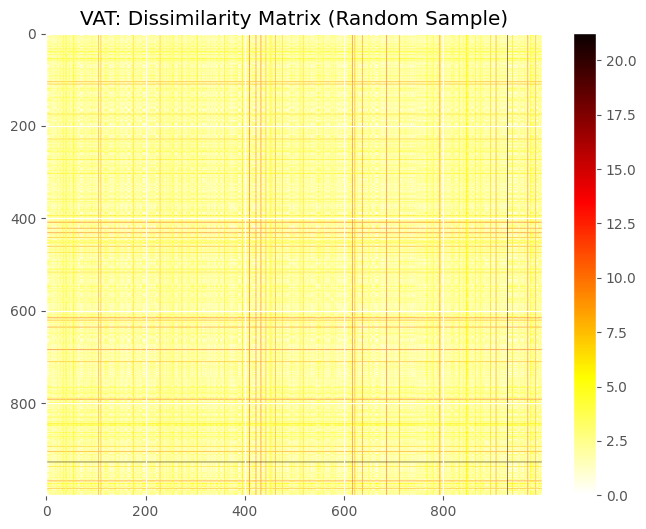

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt

def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)
    
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
    rand_X = np.random.uniform(X.min(axis=0), X.max(axis=0), (m, d))
    
    u_dist = []
    for j in range(0, m):
        u_dist.append(nbrs.kneighbors(rand_X[j].reshape(1, -1), return_distance=True)[0][0][0])
    
    w_dist = nbrs.kneighbors(X.sample(m).values, return_distance=True)[0]
    
    u_sum = np.sum(u_dist)
    w_sum = np.sum(w_dist)
    
    H = u_sum / (u_sum + w_sum)
    return H

sample_n = 5000
if len(df_scaled) > sample_n:
    X_sample = df_scaled.sample(sample_n, random_state=42)
else:
    X_sample = df_scaled

print(f"Hopkins Statistic: {hopkins(X_sample):.4f}")
print("(Valores cercanos a 1 indican alta tendencia de agrupamiento)")

# VAT
X_vat = df_scaled.sample(1000, random_state=42)
dist_matrix = pairwise_distances(X_vat)
np.fill_diagonal(dist_matrix, 0)

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix, cmap='hot_r', aspect='auto')
plt.colorbar()
plt.title("VAT: Matriz de Disimilaridad")
plt.show()

**Evaluación de tendencia de agrupamiento (Hopkins y VAT)**

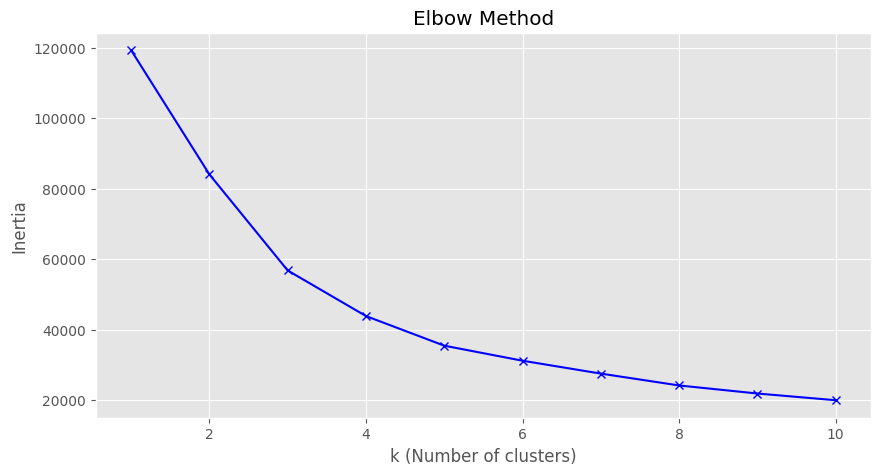

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k (Número de clusters)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

**Determinación del número óptimo de clusters**

Silhouette Score (K-Means): 0.5347
Silhouette Score (Hierarchical): 0.7150


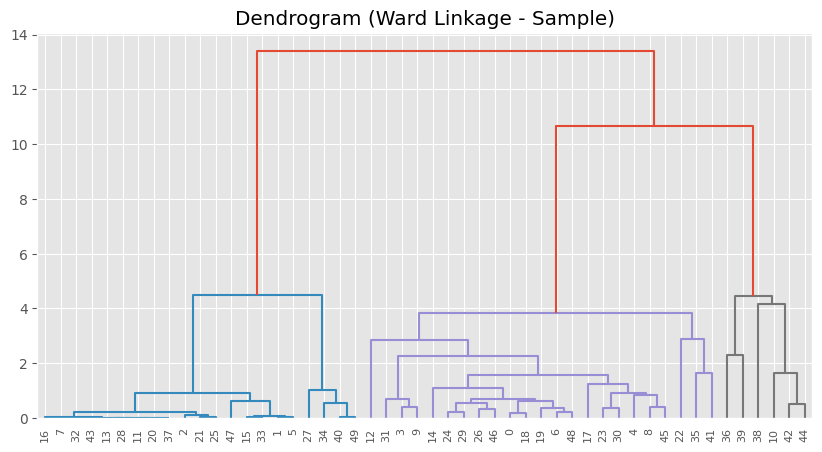

In [ ]:
k = 4

# K-Means
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Clustering Jerárquico
agg_cluster = AgglomerativeClustering(n_clusters=k)
X_hierarchical = X_scaled[:10000] 
agg_labels = agg_cluster.fit_predict(X_hierarchical)

# Evaluación con Silhouette Score
from sklearn.utils import resample
X_sil, k_lab_sil = resample(X_scaled, kmeans_labels, n_samples=5000, random_state=42)
X_sil_h, h_lab_sil = resample(X_hierarchical, agg_labels, n_samples=5000, random_state=42)

print(f"Silhouette Score (K-Means): {silhouette_score(X_sil, k_lab_sil):.4f}")
print(f"Silhouette Score (Jerárquico): {silhouette_score(X_sil_h, h_lab_sil):.4f}")

# Dendrograma
plt.figure(figsize=(10, 5))
plt.title("Dendrograma (Ward Linkage)")
dendrogram(linkage(X_sil[:50], method='ward'))
plt.show()

**Aplicación de K-Means y clustering jerárquico**

Cluster Centers (Mean Values):


,budget,revenue,runtime,voteAvg,voteCount,popularity
Cluster,,,,,,
0,1.346094e+04,2.340372e+04,24.891612,0.176328,0.271206,0.784116
1,9.801185e+06,2.270055e+07,95.148880,6.537914,718.378057,35.063838
2,1.142884e+08,4.582054e+08,120.948179,6.942885,8054.770308,125.600359
3,1.050000e+08,3.542120e+08,122.750000,7.425000,2350.750000,6416.893875



Cluster Sizes:
Cluster
1    10673
0     8488
2      714
3        8
Name: count, dtype: int64


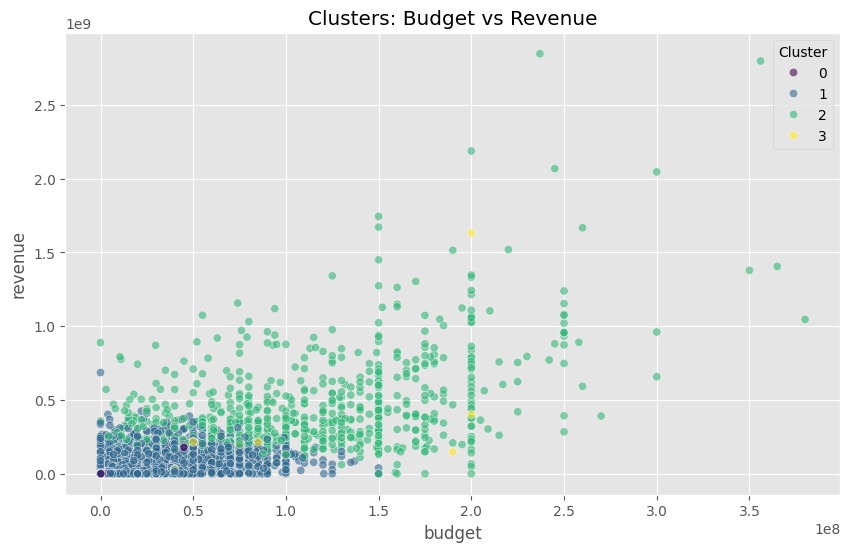

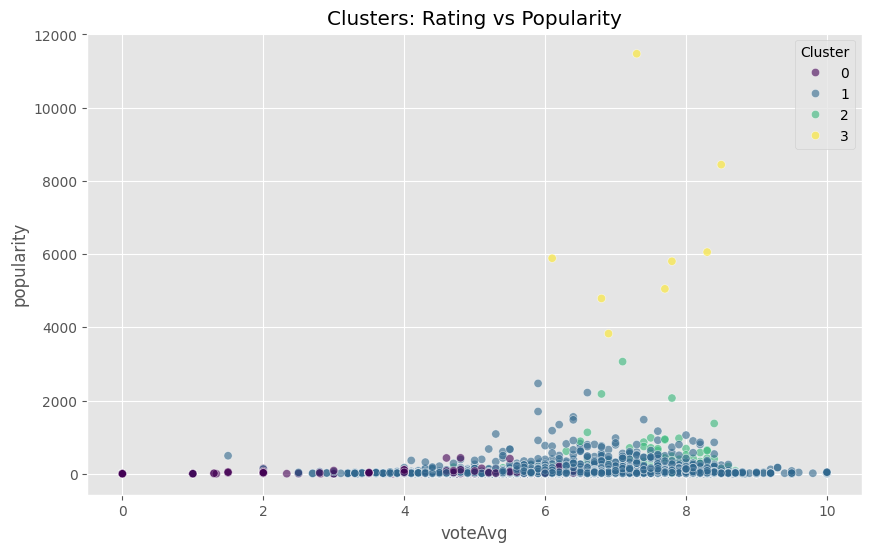

In [ ]:
df_cluster['Cluster'] = kmeans_labels

print("Centros de Clusters (Valores Medios):")
display(df_cluster.groupby('Cluster').mean())

print("\nTamaño de Clusters:")
print(df_cluster['Cluster'].value_counts())

# Visualización: Presupuesto vs Ingresos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='budget', y='revenue', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Clusters: Presupuesto vs Ingresos')
plt.show()

# Visualización: Calificación vs Popularidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='voteAvg', y='popularity', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Clusters: Calificación vs Popularidad')
plt.show()

**Interpretación y visualización de resultados**